In [3]:
pip install ctgan

Dataset loaded. Shape: (244, 7)
Categorical columns converted to string
Encoded conditional columns: ['smoker_No', 'smoker_Yes', 'time_Dinner', 'time_Lunch']
Conditional columns one-hot encoded and removed
Final training DataFrame shape: (244, 9)
Final columns: ['total_bill', 'tip', 'sex', 'day', 'size', 'smoker_No', 'smoker_Yes', 'time_Dinner', 'time_Lunch']
Discrete columns: ['sex', 'day', 'smoker_No', 'smoker_Yes', 'time_Dinner', 'time_Lunch']
Model trained!

Conditional synthetic samples:
   total_bill       tip     sex   day  size  smoker_No  smoker_Yes  \
0   18.478751  3.713575    Male   Sat     2          0           1   
1   43.320598  4.653790    Male   Sun     4          0           1   
2   16.839032  1.519899  Female  Thur     2          0           1   
3   32.399937  1.980801  Female  Thur     2          0           1   
4   15.696210  2.302159  Female  Thur     2          0           1   

   time_Dinner  time_Lunch  
0            1           0  
1            1         

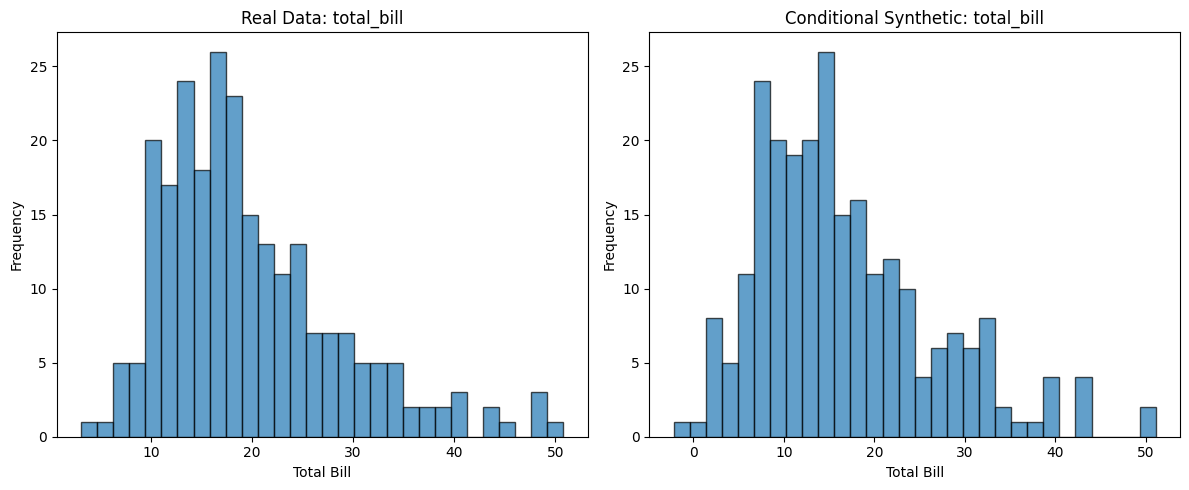


Real `day` value counts:
day
Fri     19
Sat     87
Sun     76
Thur    62
Name: count, dtype: int64

Synthetic (unconditional) `day` value counts:
day
Fri     17
Sat     85
Sun     79
Thur    63
Name: count, dtype: int64


In [4]:
# ========== STEP 1: Install and Import ==========
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ctgan import CTGAN

# ========== STEP 2: Load Dataset ==========
data = sns.load_dataset("tips")
print("Dataset loaded. Shape:", data.shape)

# ========== STEP 3: Prepare Categorical Columns ==========
categorical_columns = data.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_columns:
    data[col] = data[col].astype(str)
print("Categorical columns converted to string")

# ========== STEP 4: Prepare Conditional Columns ==========
conditional_columns = ['smoker', 'time']

# One-hot encode using pandas (keep all categories)
encoded_df = pd.get_dummies(data[conditional_columns])
print("Encoded conditional columns:", encoded_df.columns.tolist())

# Remove the original conditional columns
data_processed = data.drop(columns=conditional_columns)
print("Conditional columns one-hot encoded and removed")

# ========== STEP 5: Merge Data ==========
final_data = pd.concat([data_processed, encoded_df], axis=1)
print("Final training DataFrame shape:", final_data.shape)
print("Final columns:", final_data.columns.tolist())

# ========== STEP 6: Train CTGAN Model ==========
# Treat all original categorical columns except conditional ones as discrete
discrete_columns = [col for col in categorical_columns if col not in conditional_columns]

discrete_columns += encoded_df.columns.tolist()

print("Discrete columns:", discrete_columns)

ctgan = CTGAN(epochs=1000, batch_size=100)
ctgan.fit(final_data, discrete_columns=discrete_columns)
print("Model trained!")

# ========== STEP 7: Conditional Sampling Function ==========
def conditional_sample(model, conditions, n_samples):
    synthetic_data = model.sample(n_samples)
    for col, value in conditions.items():
        if col in synthetic_data.columns:
            synthetic_data[col] = value
    return synthetic_data

# ========== STEP 8: Generate Conditional Samples ==========
conditions = {
    'smoker_Yes': 1,
    'smoker_No': 0,
    'time_Lunch': 0,
    'time_Dinner': 1
}
conditional_samples = conditional_sample(ctgan, conditions, n_samples=244)
print("\nConditional synthetic samples:")
print(conditional_samples.head())

# ========== STEP 9: Generate Unconditional Samples ==========
unconditional_samples = ctgan.sample(244)
print("\nUnconditional synthetic samples:")
print(unconditional_samples.head())

# ========== STEP 10: Compare Distributions ==========
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data['total_bill'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Real Data: total_bill')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(conditional_samples['total_bill'], bins=30, alpha=0.7, edgecolor='black')
plt.title('Conditional Synthetic: total_bill')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nReal `day` value counts:")
print(data['day'].value_counts().sort_index())

print("\nSynthetic (unconditional) `day` value counts:")
print(unconditional_samples['day'].value_counts().sort_index())
